# Expected Loss Estimation

This notebook estimates Expected Credit Loss using the output of the Probability of Default model.

The key credit risk formula is:

Expected Loss = PD × LGD × EAD

Where:

- PD = Probability of Default
- LGD = Loss Given Default
- EAD = Exposure at Default

Since the public dataset does not contain actual loan exposure or recovery data, LGD and EAD are assumed for demonstration purposes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
results = pd.read_csv("../data/processed/pd_model_predictions.csv")

results.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Actual_Default,Predicted_Default,Probability_of_Default,Risk_Band
0,0.019252,66,0,0.433926,5175.0,13,0,1,0,0.0,0,0,0.275552,High Risk
1,0.454221,78,0,0.873533,2300.0,7,0,1,0,2.0,0,0,0.247342,High Risk
2,0.077572,59,0,0.172882,10833.0,5,0,1,0,0.0,0,0,0.297428,High Risk
3,0.107864,59,0,0.453692,9900.0,10,0,2,0,0.0,0,0,0.314718,Very High Risk
4,0.101095,67,0,0.407831,5950.0,14,0,2,0,0.0,0,0,0.280966,High Risk


In [5]:
results.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'Actual_Default', 'Predicted_Default',
       'Probability_of_Default', 'Risk_Band'],
      dtype='str')

## LGD and EAD Assumptions

The dataset does not provide actual loan amount, exposure, collateral value, or recovery amount.

Therefore, for this first version of the project:

- LGD is assumed to be 45%
- EAD is assumed to be ₹100,000 per borrower

These assumptions are used only to demonstrate the Expected Loss framework.

In [7]:
LGD = 0.45
EAD = 100000

print(f"Assumed LGD: {LGD:.0%}")
print(f"Assumed EAD: ₹{EAD:,.0f}")

Assumed LGD: 45%
Assumed EAD: ₹100,000


In [9]:
results["LGD"] = LGD
results["EAD"] = EAD

results["Expected_Loss"] = (
    results["Probability_of_Default"] *
    results["LGD"] *
    results["EAD"]
)

results[["Probability_of_Default", "LGD", "EAD", "Expected_Loss", "Risk_Band"]].head()

,Probability_of_Default,LGD,EAD,Expected_Loss,Risk_Band
0,0.275552,0.45,100000,12399.842459,High Risk
1,0.247342,0.45,100000,11130.392672,High Risk
2,0.297428,0.45,100000,13384.247865,High Risk
3,0.314718,0.45,100000,14162.322983,Very High Risk
4,0.280966,0.45,100000,12643.489402,High Risk


In [10]:
sample_borrower = results[["Probability_of_Default", "LGD", "EAD", "Expected_Loss", "Risk_Band"]].head(1)

sample_borrower

,Probability_of_Default,LGD,EAD,Expected_Loss,Risk_Band
0,0.275552,0.45,100000,12399.842459,High Risk


For one borrower, Expected Loss represents the average estimated credit loss based on the borrower's predicted probability of default, assumed loss severity, and assumed exposure amount.

For example, if a borrower has:

- PD = 10%
- LGD = 45%
- EAD = ₹100,000

Then:

Expected Loss = 10% × 45% × ₹100,000 = ₹4,500

In [12]:
total_expected_loss = results["Expected_Loss"].sum()
average_expected_loss = results["Expected_Loss"].mean()

print(f"Total Portfolio Expected Loss: ₹{total_expected_loss:,.2f}")
print(f"Average Expected Loss per Borrower: ₹{average_expected_loss:,.2f}")

Total Portfolio Expected Loss: ₹557,754,606.54
Average Expected Loss per Borrower: ₹18,591.82


In [13]:
risk_band_el_summary = results.groupby("Risk_Band").agg(
    Borrower_Count=("Expected_Loss", "count"),
    Average_PD=("Probability_of_Default", "mean"),
    Average_Expected_Loss=("Expected_Loss", "mean"),
    Total_Expected_Loss=("Expected_Loss", "sum")
).sort_values("Average_PD")

risk_band_el_summary

,Borrower_Count,Average_PD,Average_Expected_Loss,Total_Expected_Loss
Risk_Band,,,,
Low Risk,16,0.014762,664.310773,1.062897e+04
Medium Risk,144,0.129989,5849.516734,8.423304e+05
High Risk,7350,0.245953,11067.901141,8.134907e+07
Very High Risk,22490,0.469890,21145.067753,4.755526e+08


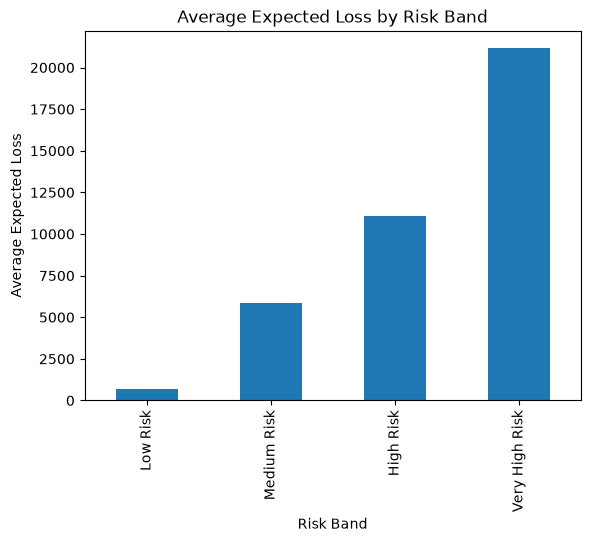

In [14]:
risk_band_el_summary["Average_Expected_Loss"].plot(kind="bar")

plt.title("Average Expected Loss by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Average Expected Loss")
plt.show()

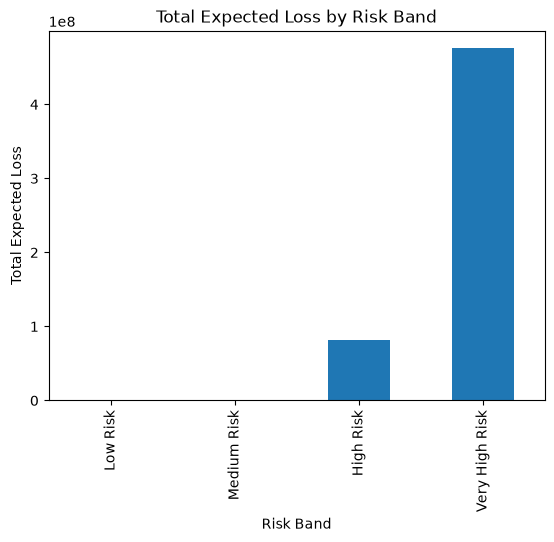

In [16]:
risk_band_el_summary["Total_Expected_Loss"].plot(kind="bar")

plt.title("Total Expected Loss by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Total Expected Loss")
plt.show()

In [17]:
final_output = results[
    [
        "Actual_Default",
        "Predicted_Default",
        "Probability_of_Default",
        "Risk_Band",
        "LGD",
        "EAD",
        "Expected_Loss"
    ]
]

final_output.head()

,Actual_Default,Predicted_Default,Probability_of_Default,Risk_Band,LGD,EAD,Expected_Loss
0,0,0,0.275552,High Risk,0.45,100000,12399.842459
1,0,0,0.247342,High Risk,0.45,100000,11130.392672
2,0,0,0.297428,High Risk,0.45,100000,13384.247865
3,0,0,0.314718,Very High Risk,0.45,100000,14162.322983
4,0,0,0.280966,High Risk,0.45,100000,12643.489402


In [18]:
final_output.to_csv("../data/processed/expected_loss_output.csv", index=False)

## Expected Loss Interpretation

The Expected Loss calculation converts the Probability of Default model into a financial risk estimate.

Instead of only predicting whether a borrower may default, the model now estimates the expected monetary loss for each borrower.

The expected loss framework helps lenders:

1. Rank borrowers by credit risk
2. Estimate portfolio-level credit loss
3. Identify high-risk borrower segments
4. Support provisioning and risk-based lending decisions

The highest-risk bands are expected to show higher average expected loss because they have higher predicted probability of default.

This completes the basic credit risk modelling flow:

Data Understanding → EDA → PD Model → Risk Bands → Expected Loss Estimation